In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex','grid'])
from pathlib import Path
import numpy as np

In [ ]:
seed = 69
rng = np.random.default_rng(seed)
FIG_DIR = Path("/Users/michelefanelli/Documents/Thesis/Latex/Figures")
FIG_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv("Data/log_returns.csv", index_col=0, parse_dates=True)
df_wnan = pd.read_csv("Data/test.csv", index_col=0, parse_dates=True)

# Imputation models

Apply every model from `Models.py` to the masked panel `df_wnan` and score the
reconstruction against the complete panel `df`. Models are run in the order
defined in the module: Deletion → Student-t EM → KNN → BRITS → SAITS → CSDI.

In [3]:
import numpy as np
from Models import (
    DeletionImputer,
    StudentTEMImputer,
    KNNReturnImputer,
    BRITSImputer,
    SAITSImputer,
    CSDIImputer,
)

# df       -> complete ground-truth panel (no missing values)
# df_wnan  -> same panel with values masked out (what we impute)
X_true = df.to_numpy(dtype=float)
X_nan = df_wnan.to_numpy(dtype=float)

# Evaluation targets: cells masked out in df_wnan but known in df.
eval_mask = np.isnan(X_nan) & ~np.isnan(X_true)
print(f"panel shape: {X_nan.shape}  |  cells to evaluate: {int(eval_mask.sum())}")

panel shape: (4125, 50)  |  cells to evaluate: 20037


### Deletion baseline

Naive complete-case baseline. It drops any row/column that contains a missing
value, so it changes the panel shape and is not directly comparable with the
shape-preserving imputers — it is included only as a reference point.

In [7]:
del_row = DeletionImputer(strategy="row").fit_transform(df_wnan)
print(f"row deletion : {X_nan.shape} -> {del_row.shape}")

row deletion : (4125, 50) -> (18, 50)


### Fit & transform the imputers

Each imputer reconstructs the full `(T, N)` panel from `df_wnan`. Observed entries
are preserved exactly, so only the masked cells are actually filled in.

In [5]:
models = {
    "Student-t EM": StudentTEMImputer(max_iter=100, nu=5.0),
    "KNN":          KNNReturnImputer(n_neighbors=5, weights="distance"),
    "BRITS":        BRITSImputer(epochs=50),
    "SAITS":        SAITSImputer(epochs=50),
    "CSDI":         CSDIImputer(epochs=50),
}

models = {
    "Student-t EM": StudentTEMImputer(max_iter=100, nu=5.0),
    "KNN":          KNNReturnImputer(n_neighbors=5, weights="distance")}

imputed = {}
for name, model in models.items():
    try:
        X_imp = model.fit_transform(df_wnan)
        imputed[name] = pd.DataFrame(X_imp, index=df_wnan.index, columns=df_wnan.columns)
        print(f"{name:13s} imputed -> {X_imp.shape}")
    except ImportError as err:
        print(f"{name:13s} skipped  ({err})")

Student-t EM  imputed -> (4125, 50)
KNN           imputed -> (4125, 50)


### Evaluation

`MSE` / `MAE` measure the direct reconstruction error on the masked cells, while
`CovErr` and `VolErr` measure how well the cross-asset covariance matrix and the
per-asset volatilities are preserved (relative error vs. the ground-truth panel).

In [6]:
def evaluate(X_imp):
    """Direct and financial reconstruction metrics vs. the ground-truth panel `df`.

    MSE / MAE are computed only on the artificially masked cells; CovErr and
    VolErr measure how well the asset covariance matrix and per-asset
    volatilities are preserved (relative error against the complete panel).
    """
    diff = X_imp[eval_mask] - X_true[eval_mask]
    cov_true, cov_imp = np.cov(X_true, rowvar=False), np.cov(X_imp, rowvar=False)
    vol_true, vol_imp = X_true.std(axis=0), X_imp.std(axis=0)
    return {
        "MSE":    np.mean(diff ** 2),
        "MAE":    np.mean(np.abs(diff)),
        "CovErr": np.linalg.norm(cov_imp - cov_true) / np.linalg.norm(cov_true),
        "VolErr": np.mean(np.abs(vol_imp - vol_true) / vol_true),
    }

scores = pd.DataFrame(
    {name: evaluate(X.to_numpy()) for name, X in imputed.items()}
).T.sort_values("MSE")
scores

,MSE,MAE,CovErr,VolErr
Student-t EM,0.000127,0.007241,0.02525,0.022862
KNN,0.000163,0.008448,0.05286,0.033130


In [10]:
cov_true, cov_imp = np.cov(X_true, rowvar=False), np.cov(del_row, rowvar=False)
vol_true, vol_imp = X_true.std(axis=0), del_row.std(axis=0)
CovErr = np.linalg.norm(cov_imp - cov_true) / np.linalg.norm(cov_true)
VolErr = np.mean(np.abs(vol_imp - vol_true) / vol_true)

In [11]:
CovErr

np.float64(0.8519309834897125)

In [12]:
VolErr

np.float64(0.2713801983690911)

In [13]:
X_true

array([[ 0.00172753,  0.00032282, -0.00120792, ..., -0.00833141,
         0.01643116,  0.01447888],
       [-0.01603421, -0.00615589, -0.01461049, ..., -0.00827961,
         0.00519254, -0.00897561],
       [-0.00185033, -0.01045417, -0.00327638, ..., -0.00576335,
        -0.00270559,  0.00819817],
       ...,
       [ 0.00813991, -0.0081091 , -0.01093699, ..., -0.01345333,
         0.00016219, -0.00286239],
       [ 0.005326  ,  0.0341123 ,  0.06458429, ..., -0.00730629,
         0.00914819, -0.00602415],
       [-0.00144103,  0.05302018,  0.10291276, ..., -0.01789223,
         0.00149884, -0.01501186]], shape=(4125, 50))

In [17]:
imputed["KNN"].to_numpy()

array([[ 0.00172753,  0.00032282, -0.00120792, ..., -0.00833141,
         0.01643116,  0.01447888],
       [-0.01603421, -0.00615589, -0.01461049, ..., -0.00827961,
         0.00519254,  0.00268983],
       [-0.00185033, -0.01045417, -0.00327638, ..., -0.00576335,
        -0.00270559,  0.00600876],
       ...,
       [ 0.00813991, -0.0081091 , -0.01093699, ..., -0.01345333,
         0.00016219, -0.00286239],
       [ 0.005326  ,  0.0341123 ,  0.06458429, ..., -0.00730629,
         0.00914819, -0.00602415],
       [-0.00144103,  0.05302018,  0.10291276, ..., -0.01789223,
         0.00149884, -0.01501186]], shape=(4125, 50))

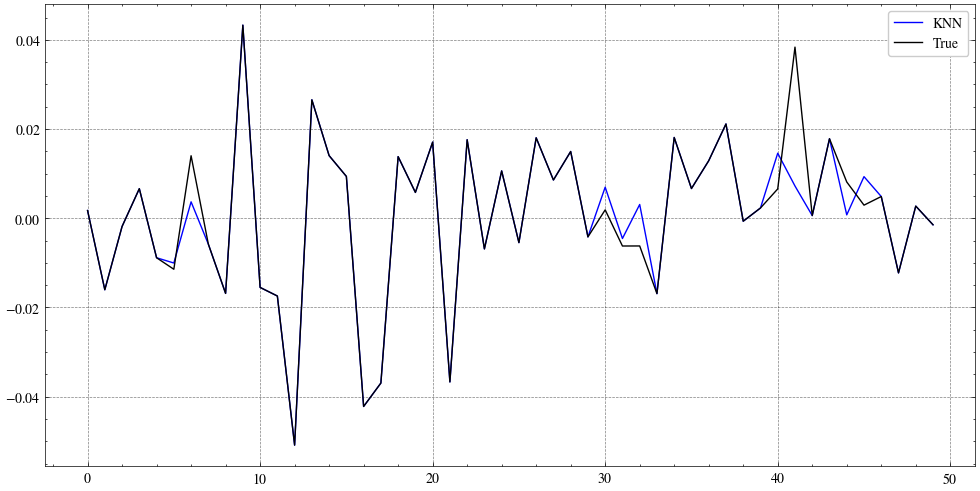

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(imputed["KNN"].to_numpy()[:50, 0], label="KNN", color="blue")
plt.plot(X_true[:50, 0], label="True", color="black")
plt.legend()
plt.show()

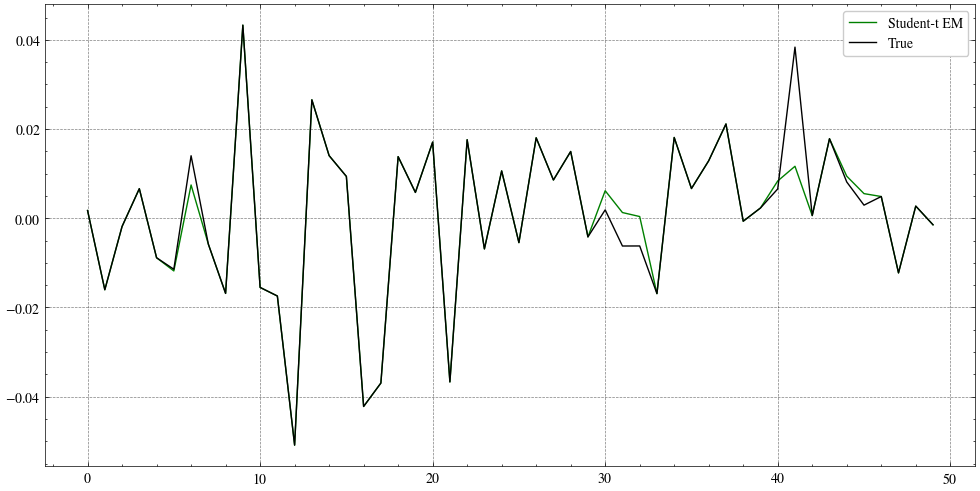

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(imputed["Student-t EM"].to_numpy()[:50, 0], label="Student-t EM", color="green")
plt.plot(X_true[:50, 0], label="True", color="black")
plt.legend()
plt.savefig("imputation_comparison.pdf", bbox_inches="tight")
plt.show()
